In [1]:
import sys; sys.path.append("../../"); sys.path.append("../../../.."); sys.path.append("../../../gmsh/"); sys.path.append("../../experiments/"); sys.path.append("../../../")
import experiment_helper
import igl
from periodic_simulation_setup import *
import json

import sys; sys.path.append("../../"); sys.path.append("../../../.."); sys.path.append("../../../gmsh/"); sys.path.append("../../experiments/"); sys.path.append("../../../")
import experiment_helper
import igl
from periodic_simulation_setup import *
import json



In [2]:
hessianShiftForStiffness = 1e-7


In [3]:
importlib.reload(pattern_generator_using_gmsh)

<module 'pattern_generator_using_gmsh' from '/Users/yren/Develop/Inflatables/python/periodic_patches/SIGGRAPH_figures/bistable_cell/../../pattern_generator_using_gmsh.py'>

In [4]:
angle = 90
r = 2.5
avg_len = 0.2


h = 5
dh = 2
dw = 3.5

m, marker = pattern_generator_using_gmsh.get_bistable_pattern(h, dh, dw, 2, avg_len)

finalMarkers = np.where(np.array(marker) == 1)[0]
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

# vertices = m.vertices()
# vertices *= 4
# m = MeshFEM.mesh.Mesh(vertices, m.elements())
fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)

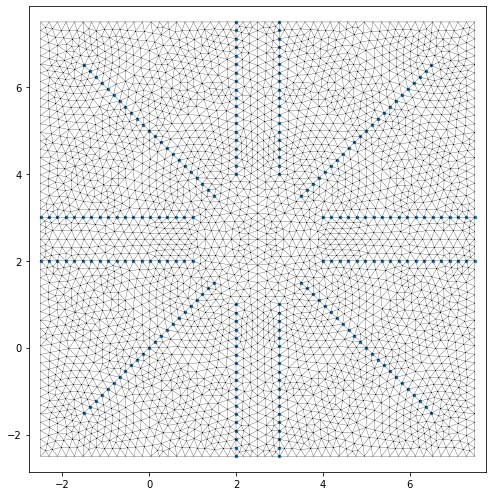

In [68]:
visualization.plot_2d_mesh(m, pointList = fusedVtx)

In [69]:
tag = "{}_{}_{}".format(h, dh, dw)
m.save("mesh_{}.obj".format(tag))
np.save("fusedVtx_{}.npy".format(tag), fusedVtx)

In [70]:
viewer = TriMeshViewer(ipu, width=768, height=640)
viewer.showWireframe(True)
viewer.show()


Renderer(camera=PerspectiveCamera(aspect=1.2, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …

In [71]:
import experiment_helper

In [72]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [73]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [74]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [75]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [18867, 18868]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.0412409	1
    Compress Matrix	0.0164909	2
    InflatablePeriodicUnit.computeAHA	0.00867701	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.000622034	1
            baseHessianSparsityPattern	9.53674e-07	1
InflatableSheet setVars	0.000149012	1
Newton iterations	12.1611	1
    InflatableSheet energy	0.000216007	3
    Newton iterate	12.1607	123
        Backtracking	0.183089	122
            InflatableSheet energy	0.0474768	692
            InflatableSheet setVars	0.0520365	234
        Compute descent direction	4.0696	122
            newton_step	4.06925	122
                Catamari Symbolic Factorize	0.0344372	1
                    CatamariConverter	0.00254893	1
                    Construct plan	0.000845909	1
                        Build	0.000531912	1
                    SparseLDL.Factor	0.00564718	1
                        supernodal_ldl.Factorization.Factor	0.00564

In [76]:
import periodic_simulation_setup

In [77]:
periodic_simulation_setup.reparametrize_gamma_bar(ipu)


In [78]:
np.save("{}_{}_{}_vars.npy".format(h, dh, dw), ipu.getVars())

In [79]:
import parametrization_helper

In [80]:
parametrization_helper.export_top_bottom_mesh(ipu.sheet, './', tag, 'inflated_shape')

In [81]:
np.set_printoptions(suppress=True, precision=4)

In [82]:
ipu.getVars()[:3], ipu.getVars()[-2:]

(array([0.7695, 0.7693, 0.    ]), array([0., 0.]))

In [83]:
kappa = ipu.getVars()[-2]
alpha = ipu.getVars()[-1]

In [84]:
z = ipu.getVars()[3:-2].reshape((-1, 3))[:, 2]

In [85]:
ipu_vars = ipu.getVars()
ipu_vars[-2] = -kappa

In [86]:
ipu.setVars(ipu_vars)